In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy.stats
from linearmodels import PanelOLS


West_EU = ["Germany", "France", "Belgium", "Netherlands", "Luxembourg", "Austria", "Ireland"]
#West_EU = ["Germany", "France", "Belgium", "Netherlands", "Austria"]
East_EU = ["Bulgaria", "Hungary", "Czechia", "Poland", "Romania", "Slovakia"]
South_EU = ["Spain", "Slovenia", "Portugal", "Italy", "Croatia", "Greece"]
Nord_EU = ["Denmark", "Sweden", "Norway", "Finland", "Estonia", "Latvia", "Lithuania"]

ALL_COUNTRIES = West_EU + East_EU + South_EU + Nord_EU
#ALL_COUNTRIES = West_EU

#TARGET = ["buildings_rest_TWh"]
TARGET = ["ln_building_rest"]
#FEATURES = ["population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC", "cdd_DegreesC"]
FEATURES = ["ln_pop", "ln_gdp_pc", "ln_hdd", "ln_cdd"]

In [21]:
# importing the transformed data prepared before
panel = pd.read_csv("Data - raw/prepared_data/panel_transformed.csv")
panel = panel[["year", "country", "population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC", "cdd_DegreesC", 'ln_pop', 'ln_gdp_pc', 'ln_hdd', 'ln_cdd', "demand_oth_TWh"]]
panel

,year,country,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,demand_oth_TWh
0,1990,Austria,7.644818,43177.35409,3.299014,3647.948556,25.646842,2.156960,10.673095,8.202194,3.282671,22.017
1,1990,Belgium,9.947782,41647.81322,3.299014,2276.951920,46.296132,2.393137,10.637028,7.731032,3.856429,26.212
2,1990,Bulgaria,8.767308,13688.68504,3.299014,2416.963240,129.481837,2.279041,9.524398,7.790681,4.871234,15.415
3,1990,Croatia,4.772556,17519.10144,3.299014,1947.345518,106.441446,1.753115,9.771104,7.574736,4.676946,6.950
4,1990,Czechia,10.362102,30937.81727,3.299014,3008.033596,32.228258,2.430283,10.339767,8.009374,3.503401,18.088
...,...,...,...,...,...,...,...,...,...,...,...,...
1217,2060,Romania,16.333523,72256.62000,1.007720,2543.820865,360.308119,2.852642,11.187993,7.841816,5.889731,NaN
1218,2060,Slovakia,4.850265,69326.40000,0.888031,2855.311013,182.376955,1.766487,11.146595,7.957286,5.211544,NaN
1219,2060,Slovenia,2.047613,81846.32000,1.617258,2240.830881,195.764920,1.114359,11.312611,7.715048,5.282010,NaN
1220,2060,Spain,53.468132,75910.47000,1.517263,1176.424436,363.398075,3.997616,11.237323,7.071085,5.898247,NaN


In [22]:
# creating the hist and proj data frames
hist = panel[(panel.year >= 2010) & (panel.year <= 2024)]

proj = panel[(panel.year >= 2025)]
proj = proj.drop(["demand_oth_TWh"], axis=1)
#proj
hist

,year,country,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,demand_oth_TWh
520,2010,Austria,8.351643,59595.26217,1.710849,3913.126161,26.592030,2.235552,10.995348,8.272347,3.317527,30.644606
521,2010,Belgium,10.839905,56252.04416,2.589410,2814.201579,38.285869,2.471476,10.937615,7.942789,3.670865,43.722700
522,2010,Bulgaria,7.421766,21707.49126,1.605189,2287.352789,150.780000,2.130820,9.985459,7.735588,5.022432,18.886000
523,2010,Croatia,4.302847,28698.16467,-1.269480,2098.359098,102.941067,1.668244,10.264623,7.649387,4.643824,12.117000
524,2010,Czechia,10.462088,38893.27089,2.685070,3488.360840,33.041979,2.439045,10.568602,8.157474,3.527594,30.801000
...,...,...,...,...,...,...,...,...,...,...,...,...
905,2024,Romania,19.067576,42788.02854,0.866539,2665.710459,232.404997,2.999105,10.664037,7.888601,5.452775,24.743164
906,2024,Slovakia,5.424687,40058.05158,1.927404,2964.396618,65.308558,1.860148,10.598110,7.994766,4.194319,11.539000
907,2024,Slovenia,2.123949,48474.69700,1.633377,2444.807005,89.379514,1.139098,10.788818,7.802130,4.504018,7.236503
908,2024,Spain,48.619695,48336.54351,3.337132,1305.524034,243.637986,3.904388,10.785964,7.175125,5.499780,157.070536


# defining plotting function

In [23]:
def plot_heat_demand(
    hist,
    proj,
    hist_actual_col="buildings_rest_TWh",
    hist_pred_col="ML_predictions",
    proj_pred_col="buildings_rest_TWh_ML",
    countries_list=None,
    train_test_split_year=2020,          # draws a dashed red vertical line
    title="Electricity Demand Buildings (excl. Heat Pumps & Data Centers): Actuals, Model Fit & Projection",
):
    if countries_list is None:
        countries_list = sorted(hist.index.get_level_values("country").unique().tolist())

    n     = len(countries_list)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(15, nrows * 3),
        constrained_layout=True,
    )
    axes_flat = axes.flatten()

    for i, country in enumerate(countries_list):
        ax = axes_flat[i]

        # ── Actual historical values (solid blue) ───────────────────────────
        try:
            actual = hist[hist_actual_col].xs(country, level="country")
            ax.plot(actual.index, actual.values,
                    "-", color="steelblue", lw=1.5, label="Actual")
        except KeyError:
            pass

        # ── Historical model predictions (dotted orange) ────────────────────
        if hist_pred_col in hist.columns:
            try:
                pred = hist[hist_pred_col].xs(country, level="country")
                ax.plot(pred.index, pred.values,
                        ":", color="darkorange", lw=1.8, label=f"Model ({hist_pred_col})")
            except KeyError:
                pass

        # ── Future projection (dashed green) ────────────────────────────────
        if proj_pred_col is not None and proj_pred_col in proj.columns:
            try:
                fut = proj[proj_pred_col].xs(country, level="country")
                ax.plot(fut.index, fut.values,
                        "--", color="seagreen", lw=1.5, label=f"Projection ({proj_pred_col})")
            except KeyError:
                pass

        # ── Train / test split line (dashed red) ────────────────────────────
        if train_test_split_year is not None:
            ax.axvline(x=train_test_split_year, color="red", lw=1.0, ls="--", alpha=0.3,
                       label=f"Train/Test split ({train_test_split_year})" if i == 0 else "_nolegend_")

        ax.set_title(country, fontsize=9, fontweight="bold")
        ax.set_ylabel("Electricity Demand (TWh)", fontsize=7)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_ylim(bottom=0)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared legend above the grid
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.04)

    return None

# preparing historical data of data centers and heat pumps to be subtracted from historical demand_oth_TWh

In [24]:
# reading historical data of data centers
dc_hist = pd.read_excel("Results/data_centers_demand.xlsx", sheet_name="Historical_2010_2024", index_col="country")

dc_hist = dc_hist.loc[:, [y for y in range(2010, 2025)]]
dc_hist = dc_hist.head(26)

dc_hist = dc_hist.sort_index()
#dc_hist

In [25]:
# reading the historical data of heat pumps (Heat consumption in TJ)
hp_hist = pd.read_csv("Data - raw/prepared_data/hist_hp_heat_demand.csv", index_col=0)
hp_hist = hp_hist[["country", "year", "Energy_TJ"]]

# COP especific for each country (4 categories)
COP_MAP = {
    "Austria": 4.0, "Belgium": 4.0, "Bulgaria": 3.5, "Croatia": 4.3,
    "Czechia": 3.5, "Denmark": 3.3, "Estonia": 3.3, "Finland": 3.3,
    "France": 4.0,  "Germany": 4.0, "Greece": 4.3,  "Hungary": 3.5,
    "Ireland": 4.0, "Italy": 4.0,   "Latvia": 3.3,  "Lithuania": 3.3,
    "Luxembourg": 4.0, "Netherlands": 4.0, "Norway": 3.3, "Poland": 3.5,
    "Portugal": 4.3,   "Romania": 3.5,    "Slovakia": 3.5, "Slovenia": 4.3,
    "Spain": 4.3,      "Sweden": 3.3,
}
hp_hist["COP"] = hp_hist["country"].map(COP_MAP)

# calculating the electricity demand from heat demand
hp_hist["Demand_HP_TWh"] = (
    hp_hist["Energy_TJ"]
    * (1 / 3600)
    / (hp_hist["COP"])
)

# only keeping the important columns
hp_hist = hp_hist[["country", "year", "Demand_HP_TWh"]]
#hp_hist

hp_hist_wide = hp_hist.pivot(index="country", columns="year", values="Demand_HP_TWh").sort_index()
hp_hist_wide = hp_hist_wide.ffill(axis=1)
#hp_hist_wide

In [26]:
dc_hp_hist = hp_hist_wide + dc_hist
dc_hp_hist = dc_hp_hist.reset_index()
dc_hp_hist = dc_hp_hist.melt(
    id_vars="country",
    var_name="year",
    value_name="dc_hp_demand_TWh"
)

# add a new column in hist df as Building_rest_TWh, which is the whole 'Others' sector (Buildings: Demand_oth_TWh) minus heat pump and data centers.
hist = hist.set_index(["country", "year"])
dc_hp_hist = dc_hp_hist.set_index(["country", "year"])
hist = hist.join(dc_hp_hist)
hist.dc_hp_demand_TWh = hist.dc_hp_demand_TWh.fillna(0)

hist["buildings_rest_TWh"] = hist["demand_oth_TWh"] - hist["dc_hp_demand_TWh"]

hist = hist.drop(["demand_oth_TWh", "dc_hp_demand_TWh"], axis=1).reset_index()
#hist = hist.reset_index()

hist#[hist.country=="Germany"]

,country,year,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,buildings_rest_TWh
0,Austria,2010,8.351643,59595.26217,1.710849,3913.126161,26.592030,2.235552,10.995348,8.272347,3.317527,30.397191
1,Belgium,2010,10.839905,56252.04416,2.589410,2814.201579,38.285869,2.471476,10.937615,7.942789,3.670865,43.722700
2,Bulgaria,2010,7.421766,21707.49126,1.605189,2287.352789,150.780000,2.130820,9.985459,7.735588,5.022432,18.886000
3,Croatia,2010,4.302847,28698.16467,-1.269480,2098.359098,102.941067,1.668244,10.264623,7.649387,4.643824,12.076315
4,Czechia,2010,10.462088,38893.27089,2.685070,3488.360840,33.041979,2.439045,10.568602,8.157474,3.527594,30.801000
...,...,...,...,...,...,...,...,...,...,...,...,...
385,Romania,2024,19.067576,42788.02854,0.866539,2665.710459,232.404997,2.999105,10.664037,7.888601,5.452775,23.140999
386,Slovakia,2024,5.424687,40058.05158,1.927404,2964.396618,65.308558,1.860148,10.598110,7.994766,4.194319,10.698743
387,Slovenia,2024,2.123949,48474.69700,1.633377,2444.807005,89.379514,1.139098,10.788818,7.802130,4.504018,6.545954
388,Spain,2024,48.619695,48336.54351,3.337132,1305.524034,243.637986,3.904388,10.785964,7.175125,5.499780,151.085659


In [27]:
hist = hist.set_index(["country", "year"])
proj = proj.set_index(["country", "year"])
hist["ln_building_rest"] = np.log1p(hist["buildings_rest_TWh"])

# BSO Daten

In [28]:
bso = pd.read_excel("Heat Pump/heat_pumps.xlsx", sheet_name="heat_spec_distribution")
bso = bso[:27] # keeping only relevant data
bso = bso[bso.Country.isin(ALL_COUNTRIES)]
bso = bso.set_index("Country")

bso

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,480479871,0.226669,0.265689,0.153497,0.123125,0.141204,0.069105,0.02071
Belgium,693785280,0.411845,0.217941,0.121747,0.084841,0.064261,0.062943,0.036422
Bulgaria,321201659,0.20838,0.226748,0.145953,0.137376,0.107167,0.111183,0.063192
Croatia,182977135,0.129597,0.171136,0.183956,0.140586,0.128498,0.157216,0.089011
Czechia,387472106,0.178462,0.208683,0.203641,0.127887,0.087488,0.1155,0.078338
Denmark,341768565,0.206363,0.182657,0.200548,0.101004,0.100508,0.106585,0.102335
Estonia,27472583,0.330614,0.211147,0.085553,0.076144,0.117936,0.115091,0.063515
Finland,406877934,0.146812,0.234661,0.147952,0.186731,0.123418,0.133904,0.026521
France,3087013302,0.182696,0.141576,0.155983,0.149489,0.098669,0.147054,0.124533


In [29]:
# Importing the Data for Norway in the format Above from Excel Caculations from SSB.no website!
norway_floor = pd.read_excel("Heat Pump/Norway_building_floor_data.xlsx", sheet_name="Norway_floor_data_2020", index_col=0)


bso = pd.concat([bso, norway_floor])
bso

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,480479871,0.226669,0.265689,0.153497,0.123125,0.141204,0.069105,0.02071
Belgium,693785280,0.411845,0.217941,0.121747,0.084841,0.064261,0.062943,0.036422
Bulgaria,321201659,0.20838,0.226748,0.145953,0.137376,0.107167,0.111183,0.063192
Croatia,182977135,0.129597,0.171136,0.183956,0.140586,0.128498,0.157216,0.089011
Czechia,387472106,0.178462,0.208683,0.203641,0.127887,0.087488,0.1155,0.078338
Denmark,341768565,0.206363,0.182657,0.200548,0.101004,0.100508,0.106585,0.102335
Estonia,27472583,0.330614,0.211147,0.085553,0.076144,0.117936,0.115091,0.063515
Finland,406877934,0.146812,0.234661,0.147952,0.186731,0.123418,0.133904,0.026521
France,3087013302,0.182696,0.141576,0.155983,0.149489,0.098669,0.147054,0.124533


In [30]:
PERIOD_COLS = {
    "0-1945":"anteil 0-1945","1946-1969":"anteil 1946-1969","1970-1979":"anteil 1970-1979",
    "1980-1989":"anteil 1980-1989","1990-1999":"anteil 1990-1999","2000-2010":"anteil 2000-2010",
    "2011-now":"anteil 2011-now",
}
INTENSITY = {"0-1945":250,"1946-1969":230,"1970-1979":170,"1980-1989":135,
             "1990-1999":110,"2000-2010":85,"2011-now":50}   # kWh/m2a — calibrate to TABULA
INTENSITY_POST2020 = 35                                       # near-zero-energy new build
NEWEST_SPAN = 10                                              # 2011..2020
YEARS = list(range(2010, 2061))

# Fraction of total 2020 floor area removed from the oldest cohort(s) per year.
# Represents demolition / deep-enough renovation that a building effectively leaves its old cohort.
# Typical EU demolition rate is ~0.1–0.2 %/yr; set higher to represent cohort-exit renovations.
RENOVATION_RATE = 0.003   # 0.3 % / yr

OLD_PERIODS = ["0-1945", "1946-1969", "1970-1979", "1980-1989", "1990-1999", "2000-2010"]

def build_floor_panel(bso, years=YEARS):
    """
    Builds a yearly panel of the building stock (floor area + thermal quality) for each country.

    Starting from the 2020 BSO snapshot, this function projects how the stock evolves year by year:
    - New floor is added to '2011-now' and 'post-2020' exactly as in the original logic,
      so total floor area still grows over time.
    - Additionally, a constant annual renovation removal (RENOVATION_RATE × total 2020 floor) is
      subtracted from the pre-2011 cohorts each year, starting from the oldest ('0-1945' first).
      This models old buildings being demolished or leaving their original energy class.
    """
    out = []
    for country, r in bso.iterrows():
        At = r["gesamtfläche_m2"]                                        # total floor area in m² (2020 snapshot)
        A2020 = {p: r[c]*At for p, c in PERIOD_COLS.items()}            # absolute m² per construction period in 2020
        annual_new = A2020["2011-now"] / NEWEST_SPAN                     # implied annual new-build rate (m²/yr), based on 2011–2020 cohort
        annual_renovation = At * RENOVATION_RATE                         # constant yearly removal from oldest cohort(s)

        for y in years:
            # new-build additions — identical to original logic
            area = {p: A2020[p] for p in OLD_PERIODS}
            area["2011-now"]  = annual_new * min(max(0, y-2010), NEWEST_SPAN)  # grows 2011→2020, then frozen at 2020 level
            area["post-2020"] = annual_new * max(0, y-2020)                    # accumulates only after 2020

            # renovation removal — subtract cumulative amount from oldest cohorts first
            cumulative_renovated = annual_renovation * max(0, y - 2010)
            remaining = cumulative_renovated
            for p in OLD_PERIODS:
                if remaining <= 0:
                    break
                sub = min(area[p], remaining)
                area[p] -= sub
                remaining -= sub

            tot = sum(area.values())
            intens = {**INTENSITY, "post-2020": INTENSITY_POST2020}
            row = {"country": country, "year": y,
                   "total_floor_m2": tot,
                   "thermal_index": sum(area[p]*intens[p] for p in area)/tot}  # area-weighted avg. heat demand intensity
            for p in area: row[f"share_{p}"] = area[p]/tot
            out.append(row)
    return pd.DataFrame(out)

floor_panel = build_floor_panel(bso)
floor_panel = floor_panel[floor_panel.year.isin(panel.year)]
floor_panel

,country,year,total_floor_m2,thermal_index,share_0-1945,share_1946-1969,share_1970-1979,share_1980-1989,share_1990-1999,share_2000-2010,share_2011-now,share_post-2020
0,Austria,2010,4.705289e+08,185.745390,0.231463,0.271308,0.156744,0.125729,0.144191,0.070567,0.000000,0.000000
1,Austria,2011,4.700826e+08,185.261010,0.228616,0.271566,0.156892,0.125848,0.144328,0.070634,0.002117,0.000000
2,Austria,2012,4.696362e+08,184.775709,0.225764,0.271824,0.157042,0.125968,0.144465,0.070701,0.004238,0.000000
3,Austria,2013,4.691899e+08,184.289485,0.222907,0.272082,0.157191,0.126087,0.144602,0.070768,0.006363,0.000000
4,Austria,2014,4.687435e+08,183.802335,0.220044,0.272341,0.157341,0.126207,0.144740,0.070835,0.008492,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
1305,Norway,2040,7.266401e+08,89.151676,0.013362,0.109594,0.070087,0.065160,0.036167,0.170882,0.178249,0.356499
1310,Norway,2045,7.836941e+08,83.094847,0.002554,0.101615,0.064985,0.060416,0.033534,0.158442,0.165273,0.413182
1315,Norway,2050,8.407481e+08,77.995799,0.000000,0.087933,0.060575,0.056316,0.031258,0.147690,0.154057,0.462171
1320,Norway,2055,8.978021e+08,73.589414,0.000000,0.073760,0.056725,0.052737,0.029272,0.138304,0.144267,0.504934


In [31]:
# Adding total_floor_m2 and "thermal_index" to hist and proj to be used in the model
# total_floor_m2 shows how much area needs to be heated
# thermal_index shows how old are the buildings in a country
BUILDING_FEATURES = ["ln_total_floor"]
FEATURES = FEATURES + BUILDING_FEATURES

floor_panel["ln_total_floor"] = np.log1p(floor_panel["total_floor_m2"])
floor_panel["ln_thermal_index"] = np.log1p(floor_panel["thermal_index"])

floor_panel = floor_panel[["year", "country", "ln_total_floor", "ln_thermal_index", "total_floor_m2", "thermal_index"]].set_index(["country", "year"])
hist = hist.join(floor_panel)
proj = proj.join(floor_panel)

# PanelOLS Model

In [32]:
def predict_logaritmic(model, df, X, LN=True):
    # it gets the model (PanelOLS) and a dataFrame containing features to predict the target variable in a new column "panel_predictions"
    
    # saving the entity effects per country
    entity_effects = model.estimated_effects.groupby('country')["estimated_effects"].mean()

    # predicting the ln(Target)
    df["panel_predictions"] = model.predict(X)["predictions"]

    # adding the entity effect to ln(Target)
    df["panel_predictions"] = (
    df["panel_predictions"]
        + df.index.get_level_values("country").map(entity_effects)
    )

    # # calculate the exponential of it, because the model is on "ln"
    if LN:
        df["panel_predictions"] = np.expm1(df["panel_predictions"])

    return df

In [33]:
hist

,,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,buildings_rest_TWh,ln_building_rest,ln_total_floor,ln_thermal_index,total_floor_m2,thermal_index
country,year,,,,,,,,,,,,,,,
Austria,2010,8.351643,59595.26217,1.710849,3913.126161,26.592030,2.235552,10.995348,8.272347,3.317527,30.397191,3.446718,19.969368,5.229746,4.705289e+08,185.745390
Belgium,2010,10.839905,56252.04416,2.589410,2814.201579,38.285869,2.471476,10.937615,7.942789,3.670865,43.722700,3.800481,20.320571,5.328498,6.685162e+08,205.128168
Bulgaria,2010,7.421766,21707.49126,1.605189,2287.352789,150.780000,2.130820,9.985459,7.735588,5.022432,18.886000,2.990016,19.522303,5.199785,3.009044e+08,180.233230
Croatia,2010,4.302847,28698.16467,-1.269480,2098.359098,102.941067,1.668244,10.264623,7.649387,4.643824,12.076315,2.570803,18.931647,5.106664,1.666902e+08,164.118617
Czechia,2010,10.462088,38893.27089,2.685070,3488.360840,33.041979,2.439045,10.568602,8.157474,3.527594,30.801000,3.459498,19.693578,5.186670,3.571183e+08,177.871880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Romania,2024,19.067576,42788.02854,0.866539,2665.710459,232.404997,2.999105,10.664037,7.888601,5.452775,23.140999,3.183912,19.843282,5.044468,4.147896e+08,154.161659
Slovakia,2024,5.424687,40058.05158,1.927404,2964.396618,65.308558,1.860148,10.598110,7.994766,4.194319,10.698743,2.459481,18.897649,5.128693,1.611182e+08,167.796332
Slovenia,2024,2.123949,48474.69700,1.633377,2444.807005,89.379514,1.139098,10.788818,7.802130,4.504018,6.545954,2.021012,17.956766,5.127717,6.288171e+07,167.631709


In [34]:
X = hist[FEATURES]
Y = hist[TARGET]

#X = sm.add_constant(X)

m_panelOLS = PanelOLS(Y, X,
                      entity_effects=True,
                      ).fit(
                        #cov_type="clustered",
                        #cluster_entity=True,
                      )
m_panelOLS

Dep. Variable:,ln_building_rest,R-squared:,0.1449
Estimator:,PanelOLS,R-squared (Between):,-2.3697
No. Observations:,390,R-squared (Within):,0.1449
Date:,"Fri, Jun 26 2026",R-squared (Overall):,-2.3693
Time:,11:24:47,Log-likelihood,678.58
Cov. Estimator:,Unadjusted,,
,,F-statistic:,12.170
Entities:,26,P-value,0.0000
Avg Obs:,15.000,Distribution:,"F(5,359)"
Min Obs:,15.000,,
Max Obs:,15.000,F-statistic (robust):,12.170


In [35]:
# predictions for historical data
hist = predict_logaritmic(m_panelOLS, hist, X, LN=True)

# Raw model projection 2025–2060
X_proj = proj[FEATURES]
#X_proj = sm.add_constant(X_proj)
proj = predict_logaritmic(m_panelOLS, proj, X_proj, LN=True)

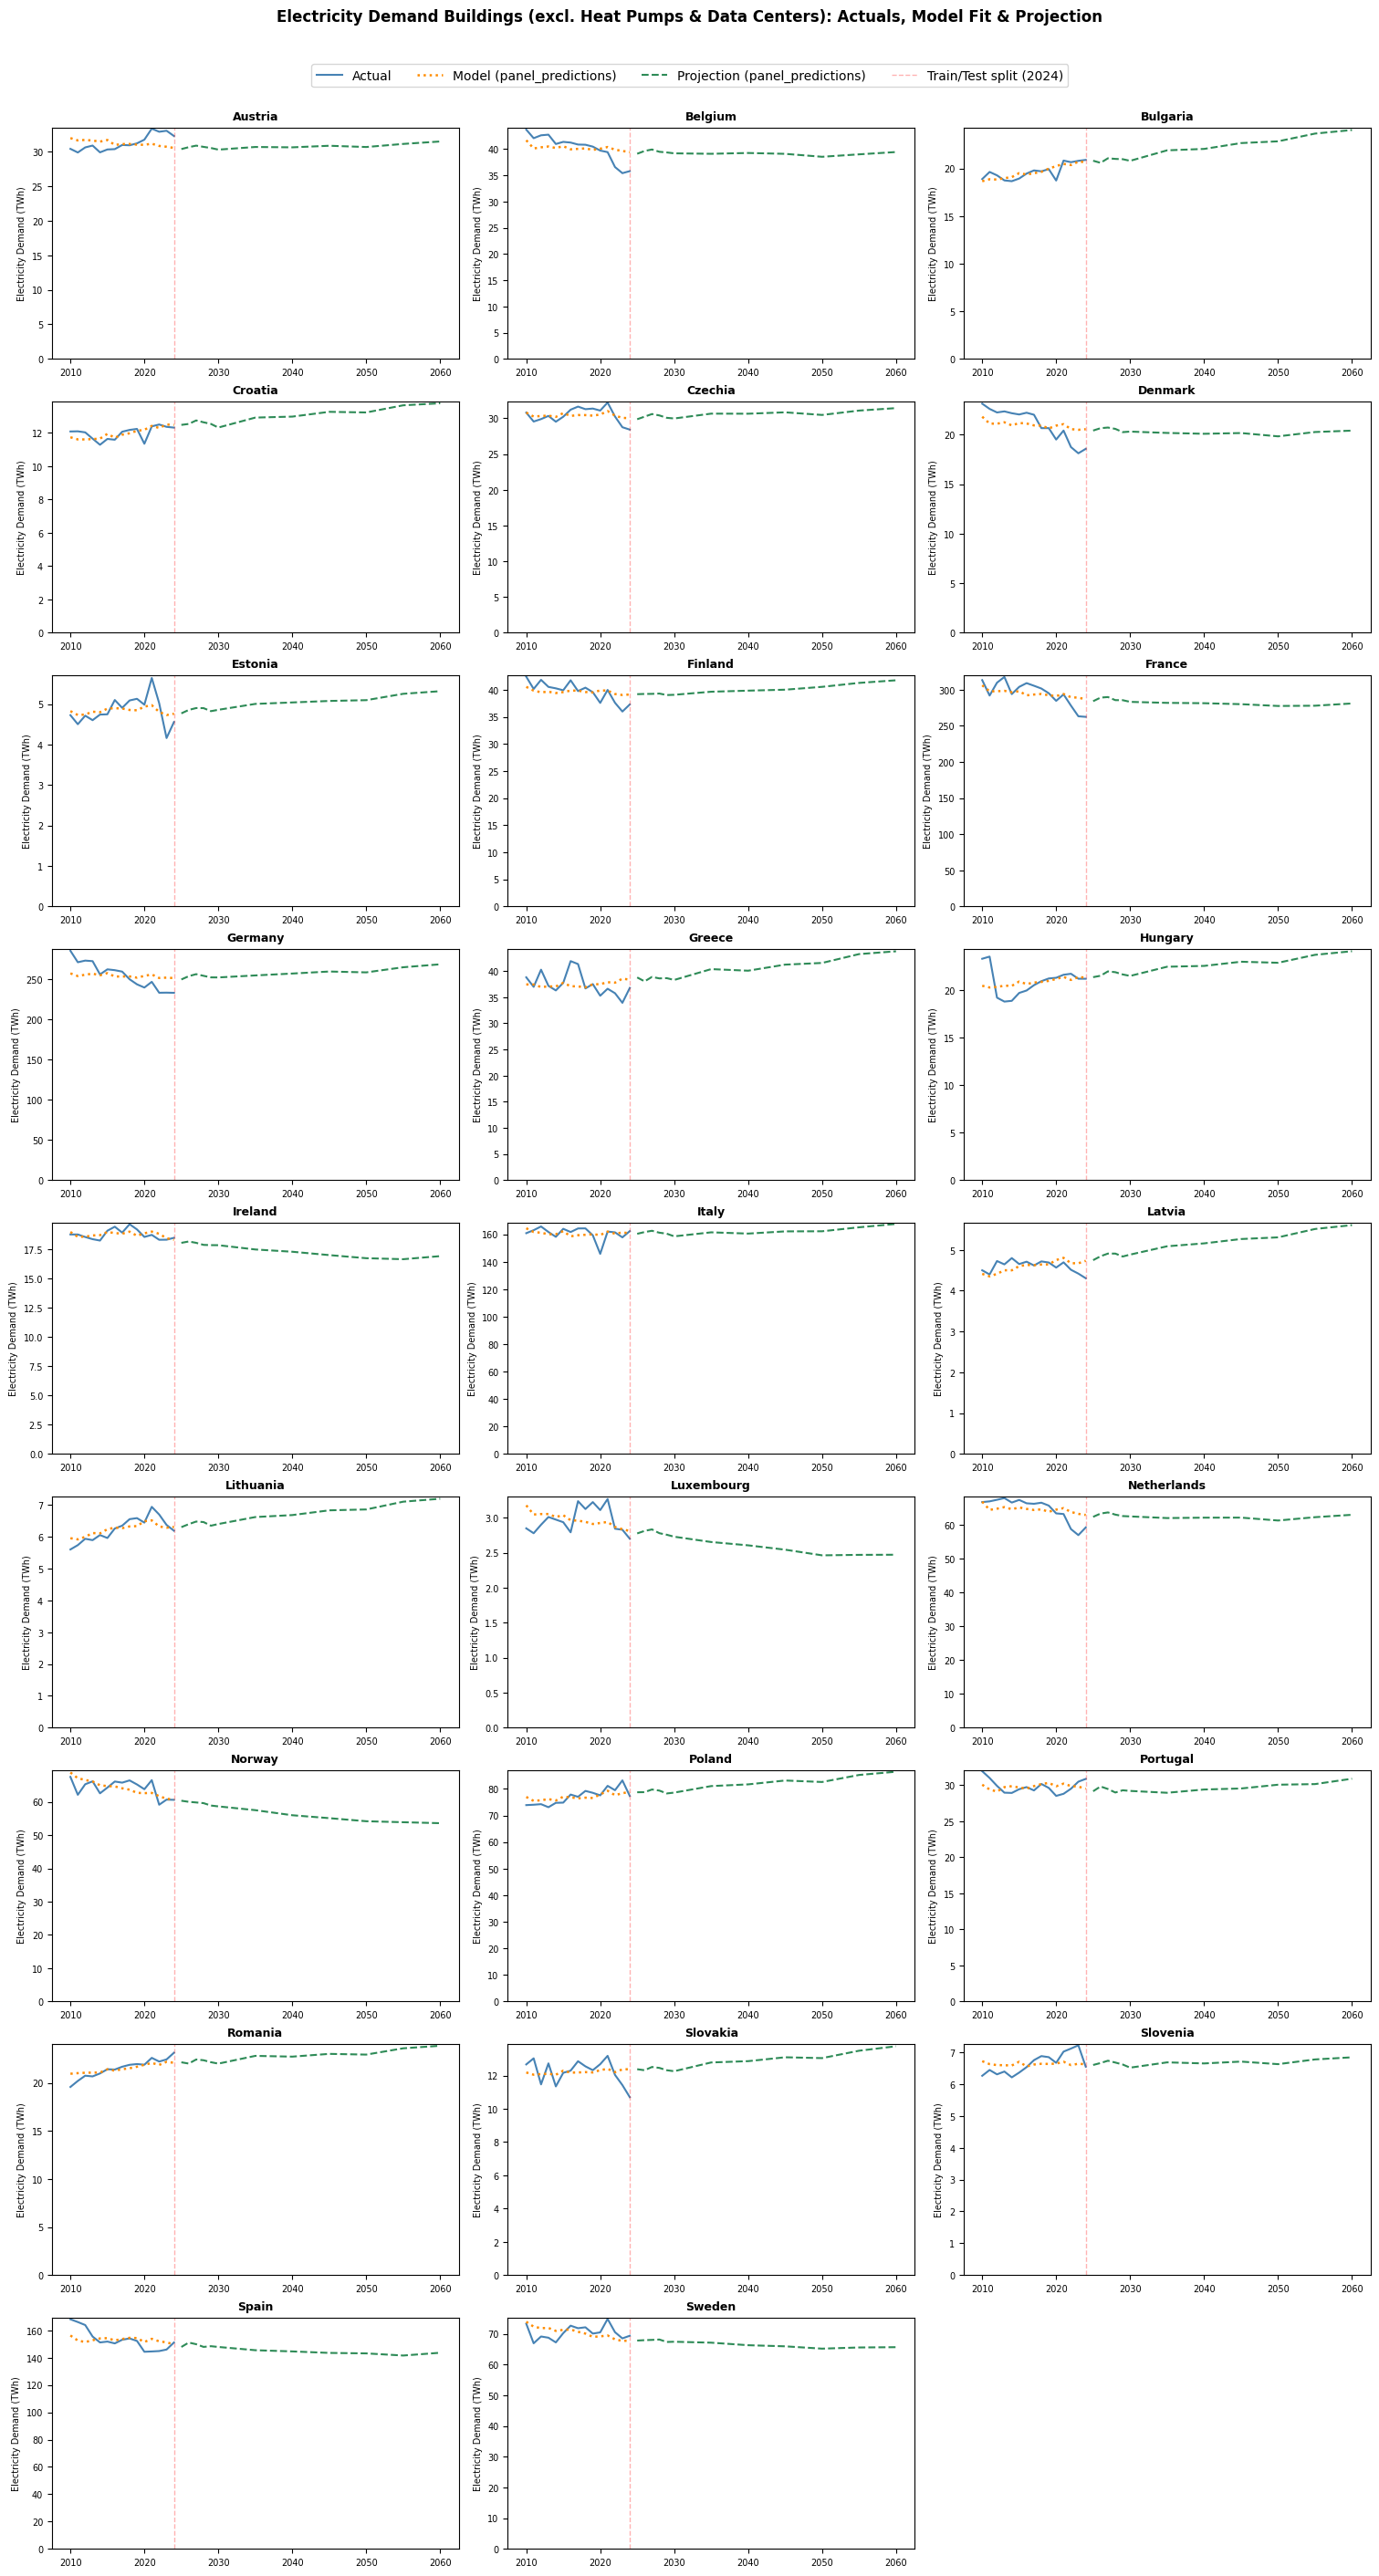

In [36]:
# plotting the results of PanelOLS model
plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="buildings_rest_TWh",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="panel_predictions",          # change to "Total_Heat_TJ_ML" when ready
    train_test_split_year=hist.index.get_level_values('year').max()
)

In [37]:
proj[proj.index.get_level_values("country").isin(["Germany"])]

population_Mio  gdp_per_capita_USD  gdp_growth_rate_Percent  \
country year                                                                
Germany 2025       83.577140         62128.11189                 0.402901   
        2026       83.499996         62924.90581                 1.189015   
        2027       83.377681         63547.13000                 0.840903   
        2028       83.250170         64127.54000                 0.759025   
        2029       83.122146         64683.70000                 0.712156   
        2030       82.990067         65264.19000                 0.737105   
        2035       82.331992         69040.80000                 1.163004   
        2040       81.721963         74568.03000                 1.459517   
        2045       81.050460         80540.13000                 1.305019   
        2050       80.277587         86404.64000                 1.178026   
        2055       79.415128         92169.80000                 1.056781   
        2060       78.505228         98654.39000                 1.223914   

              hdd_DegreesC  cdd_DegreesC    ln_pop  ln_gdp_pc    ln_hdd  \
country year                                                              
Germany 2025   2461.934004     17.403123  4.437664  11.036970  7.809109   
        2026   2912.511039     23.298619  4.436751  11.049713  7.977114   
        2027   3141.458422     46.628866  4.435303  11.059553  8.052761   
        2028   2745.421863     78.190539  4.433791  11.068645  7.918054   
        2029   2464.020376     77.267424  4.432270  11.077280  7.809955   
        2030   2373.458405    117.095232  4.430699  11.086214  7.772525   
        2035   2556.867923     30.099023  4.422833  11.142467  7.846929   
        2040   2551.776111     27.038250  4.415485  11.219481  7.844937   
        2045   2468.586279     57.402847  4.407334  11.296523  7.811806   
        2050   2047.838406     80.641767  4.397870  11.366808  7.625028   
        2055   2462.241292     55.920372  4.387202  11.431399  7.809233   
        2060   2497.037922     92.541102  4.375823  11.499388  7.823261   

                ln_cdd  ln_total_floor  ln_thermal_index  total_floor_m2  \
country year                                                               
Germany 2025  2.912520       22.036634          5.183172    3.718678e+09   
        2026  3.190420       22.037940          5.178417    3.723538e+09   
        2027  3.863439       22.039245          5.173653    3.728399e+09   
        2028  4.371857       22.040548          5.168878    3.733260e+09   
        2029  4.360131       22.041849          5.164093    3.738120e+09   
        2030  4.771491       22.043148          5.159297    3.742981e+09   
        2035  3.437176       22.049620          5.135158    3.767284e+09   
        2040  3.333570       22.056051          5.110742    3.791588e+09   
        2045  4.067365       22.062440          5.086039    3.815891e+09   
        2050  4.402341       22.068789          5.061034    3.840194e+09   
        2055  4.041653       22.075098          5.035715    3.864498e+09   
        2060  4.538401       22.081367          5.010067    3.888801e+09   

              thermal_index  panel_predictions  
country year                                    
Germany 2025     177.247230         249.259483  
        2026     176.401802         253.326281  
        2027     175.558578         255.836626  
        2028     174.717550         253.778040  
        2029     173.878708         251.852992  
        2030     173.042046         251.765766  
        2035     168.891118         254.262703  
        2040     164.793404         256.609836  
        2045     160.747886         259.130225  
        2050     156.753574         258.061035  
        2055     152.809501         264.420383  
        2060     148.914725         268.087020